In [1]:
import pandas as pd

# 导入数据集（根据你保存的格式调整路径）
train1 = pd.read_csv('C:/Users/cjmwo/meituan/train1.csv')

# 查看数据集基本信息
print(train1.head())

# 查看数据集所有列名（字段名称）
print(train1.columns)

# 更清晰地查看列名列表
print(list(train1.columns))

   id  loanAmnt  term  interestRate  installment grade subGrade  \
0   0   35000.0     5         19.52       917.97     E       E2   
1   1   18000.0     5         18.49       461.90     D       D2   
2   2   12000.0     5         16.99       298.17     D       D3   
3   3   11000.0     3          7.26       340.96     A       A4   
4   4    3000.0     3         12.99       101.07     C       C2   

   employmentTitle  employmentLength  homeOwnership  ...    n6    n7    n8  \
0            320.0               2.0              2  ...   8.0   4.0  12.0   
1         219843.0               5.0              0  ...   4.0   6.0  11.0   
2          31698.0               8.0              0  ...  21.0   4.0   5.0   
3          46854.0              10.0              1  ...   4.0   7.0  21.0   
4             54.0              -1.0              1  ...   9.0  10.0  15.0   

    n9   n10  n11  n12  n13  n14  issueDateDT  
0  2.0   7.0  0.0  0.0  0.0  2.0       2587.0  
1  4.0  13.0  0.0  0.0  0.0  1.0

In [11]:
# 计算每一列的类别数
nunique_counts = train1.nunique()

# 类别数 > 20 的列
cols_more_100 = nunique_counts[nunique_counts > 100].index.tolist()

# 类别数 <= 20 的列
cols_less_equal_100 = nunique_counts[nunique_counts <= 100].index.tolist()

print("类别数 > 20 的列：")
print(cols_more_100)

print("\n类别数 <= 20 的列：")
print(cols_less_equal_100)

类别数 > 20 的列：
['id', 'loanAmnt', 'interestRate', 'installment', 'employmentTitle', 'annualIncome', 'issueDate', 'postCode', 'dti', 'revolBal', 'revolUtil', 'totalAcc', 'title', 'n6', 'issueDateDT']

类别数 <= 20 的列：
['term', 'grade', 'subGrade', 'employmentLength', 'homeOwnership', 'verificationStatus', 'isDefault', 'purpose', 'regionCode', 'delinquency_2years', 'ficoRangeLow', 'ficoRangeHigh', 'openAcc', 'pubRec', 'pubRecBankruptcies', 'initialListStatus', 'applicationType', 'earliesCreditLine', 'policyCode', 'n0', 'n1', 'n2', 'n3', 'n4', 'n5', 'n7', 'n8', 'n9', 'n10', 'n11', 'n12', 'n13', 'n14']


In [13]:
numeric_cols = [
    'loanAmnt', 'interestRate', 'installment', 'employmentTitle',
    'annualIncome', 'postCode', 'dti', 'revolBal', 'revolUtil',
    'totalAcc', 'title', 'n6', 'issueDateDT'
]

In [15]:
import numpy as np

outlier_dict = {}

for col in numeric_cols:
    data = train1[col].dropna()
    
    mean = data.mean()
    std = data.std()
    
    lower = mean - 3 * std
    upper = mean + 3 * std
    
    outliers = train1[(train1[col] < lower) | (train1[col] > upper)]
    
    outlier_dict[col] = outliers
    
    print(f"{col} 异常值数量: {outliers.shape[0]}")

loanAmnt 异常值数量: 0
interestRate 异常值数量: 3799
installment 异常值数量: 5275
employmentTitle 异常值数量: 0
annualIncome 异常值数量: 3963
postCode 异常值数量: 703
dti 异常值数量: 1064
revolBal 异常值数量: 6718
revolUtil 异常值数量: 29
totalAcc 异常值数量: 4911
title 异常值数量: 16603
n6 异常值数量: 9275
issueDateDT 异常值数量: 4889


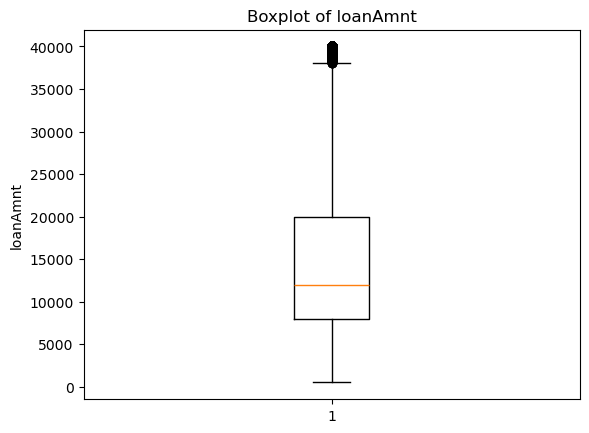

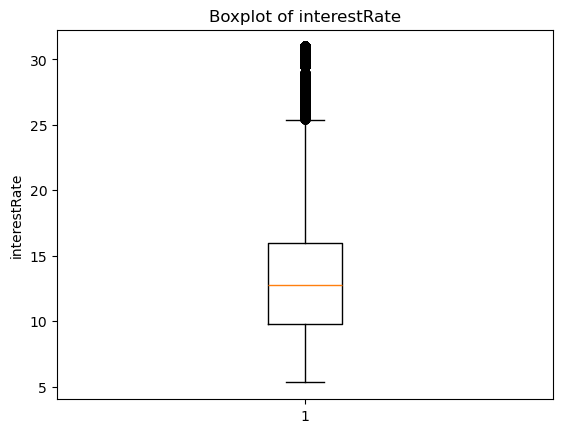

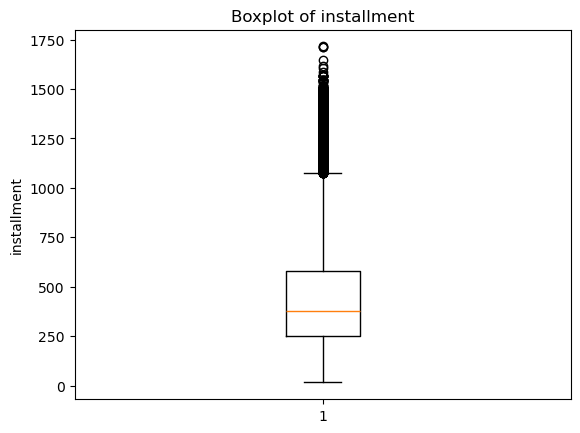

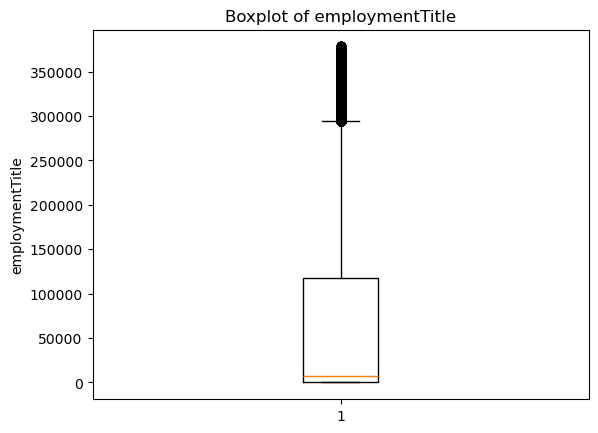

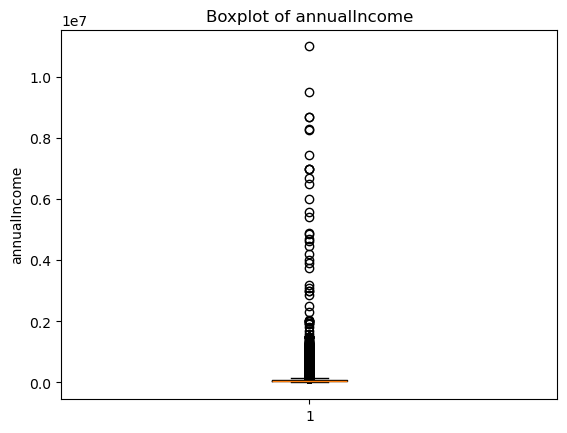

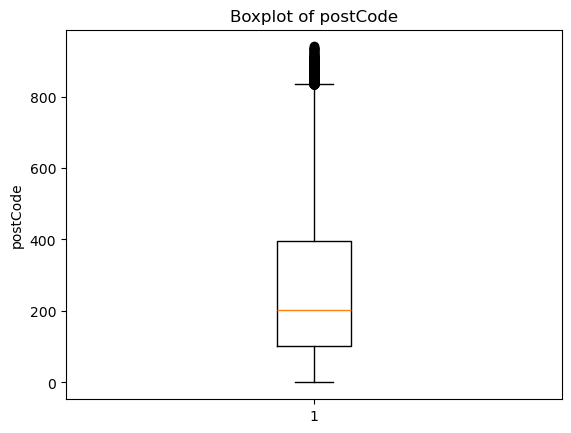

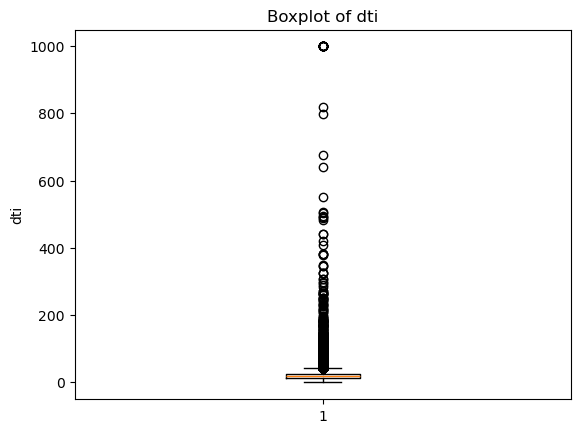

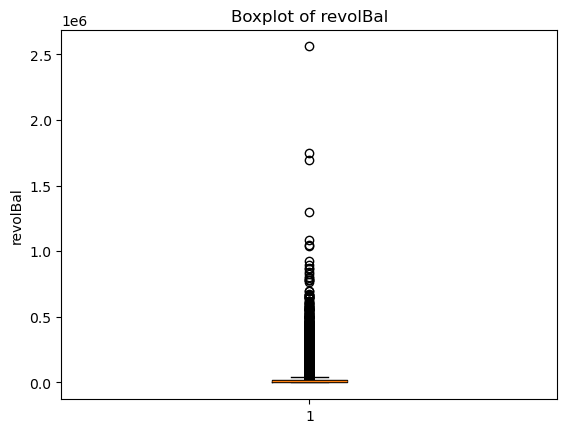

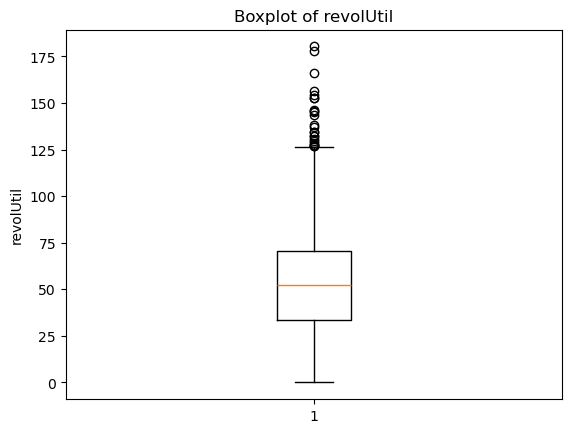

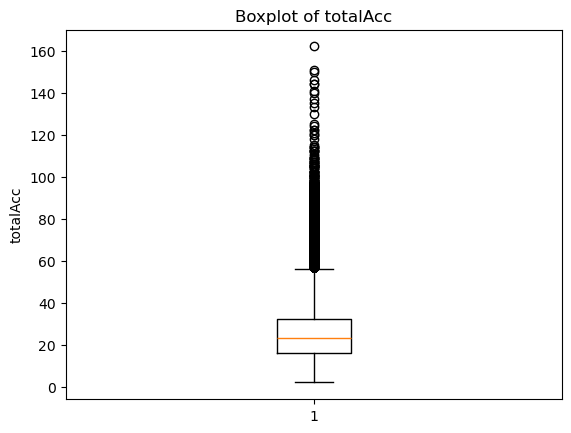

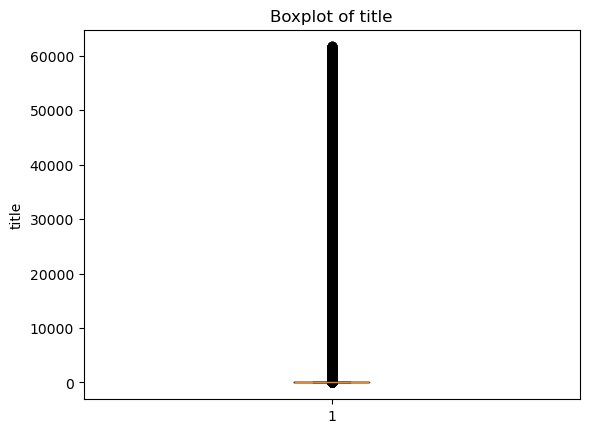

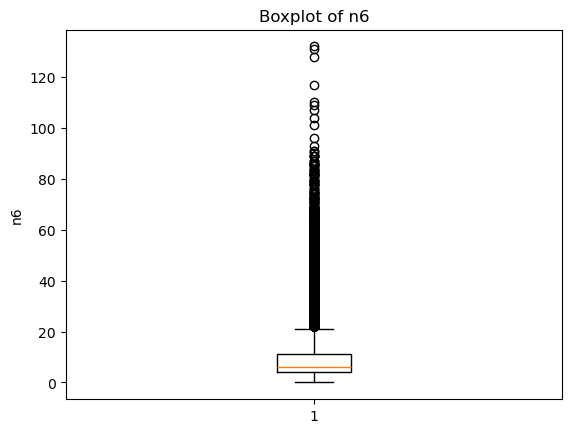

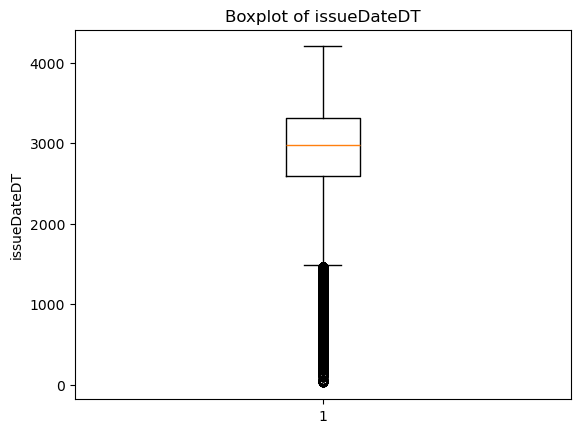

In [17]:
import matplotlib.pyplot as plt

for col in numeric_cols:
    plt.figure()
    plt.boxplot(train1[col].dropna())
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.show()

In [19]:
for col in numeric_cols:
    data = train1[col].dropna()
    
    mean = data.mean()
    std = data.std()
    
    lower = mean - 3 * std
    upper = mean + 3 * std
    
    outliers = data[(data < lower) | (data > upper)]
    
    ratio = len(outliers) / len(data)
    
    print(f"{col}: 异常值比例 {ratio:.4f}")

loanAmnt: 异常值比例 0.0000
interestRate: 异常值比例 0.0071
installment: 异常值比例 0.0099
employmentTitle: 异常值比例 0.0000
annualIncome: 异常值比例 0.0074
postCode: 异常值比例 0.0013
dti: 异常值比例 0.0020
revolBal: 异常值比例 0.0126
revolUtil: 异常值比例 0.0001
totalAcc: 异常值比例 0.0092
title: 异常值比例 0.0312
n6: 异常值比例 0.0174
issueDateDT: 异常值比例 0.0092


In [21]:
df = train1.copy()

numeric_cols = [
    'loanAmnt', 'interestRate', 'installment', 'employmentTitle',
    'annualIncome', 'postCode', 'dti', 'revolBal', 'revolUtil',
    'totalAcc', 'title', 'n6', 'issueDateDT'
]

for col in numeric_cols:
    mean = df[col].mean()
    std = df[col].std()
    
    lower = mean - 3 * std
    upper = mean + 3 * std
    
    df = df[(df[col] >= lower) & (df[col] <= upper)]

In [23]:
print("原始数据维度:", train1.shape)
print("删除异常值后维度:", df.shape)

原始数据维度: (532163, 48)
删除异常值后维度: (474957, 48)


In [25]:
print("删除行数:", train1.shape[0] - df.shape[0])

删除行数: 57206


In [27]:
features = [
    'loanAmnt', 'interestRate', 'installment', 'employmentTitle', 'annualIncome',
    'postCode', 'dti', 'revolBal', 'revolUtil', 'totalAcc', 'title', 'n6', 'issueDateDT',
    'term', 'grade', 'subGrade', 'employmentLength', 'homeOwnership', 'verificationStatus',
    'purpose', 'regionCode', 'delinquency_2years', 'ficoRangeLow', 'ficoRangeHigh',
    'openAcc', 'pubRec', 'pubRecBankruptcies', 'initialListStatus', 'applicationType',
    'earliesCreditLine', 'policyCode',
    'n0', 'n1', 'n2', 'n3', 'n4', 'n5', 'n7', 'n8', 'n9', 'n10',
    'n11', 'n12', 'n13', 'n14'
]

X = train1[features]
y = train1['isDefault']

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [31]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=1/3,
    random_state=42,
    stratify=y_temp
)

In [33]:
print("训练集:", X_train.shape, y_train.shape)
print("验证集:", X_val.shape, y_val.shape)
print("测试集:", X_test.shape, y_test.shape)

训练集: (372514, 45) (372514,)
验证集: (106432, 45) (106432,)
测试集: (53217, 45) (53217,)


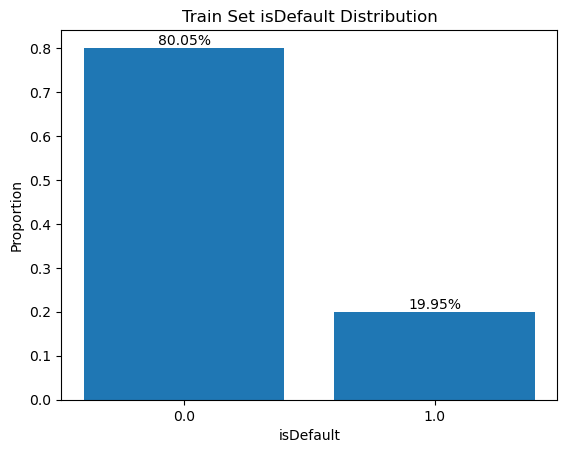

In [35]:
import matplotlib.pyplot as plt

# 计算训练集标签分布比例
dist = y_train.value_counts(normalize=True).sort_index()

# 画比例图
plt.figure()
plt.bar(dist.index.astype(str), dist.values)

plt.title("Train Set isDefault Distribution")
plt.xlabel("isDefault")
plt.ylabel("Proportion")

# 在柱子上标数值
for i, v in enumerate(dist.values):
    plt.text(i, v, f"{v:.2%}", ha='center', va='bottom')

plt.show()

In [43]:
from sklearn.preprocessing import LabelEncoder

X_train_enc = X_train.copy()

for col in X_train_enc.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X_train_enc[col] = le.fit_transform(X_train_enc[col].astype(str))

In [47]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_enc, y_train)

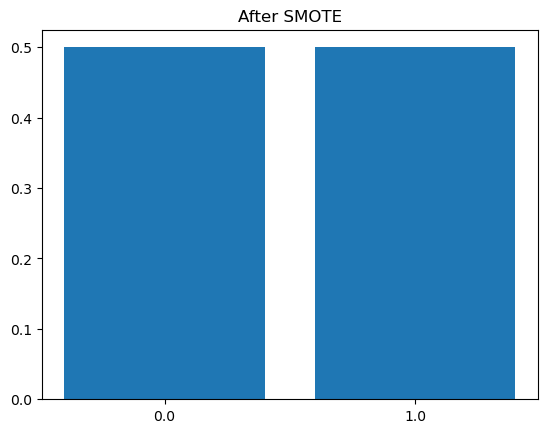

In [49]:
import matplotlib.pyplot as plt

dist = y_train_smote.value_counts(normalize=True).sort_index()

plt.figure()
plt.bar(dist.index.astype(str), dist.values)
plt.title("After SMOTE")
plt.show()

In [63]:
!pip install scorecardpy



     ---------------------------------------- 0.0/58.1 kB ? eta -:--:--
     ---------------------------------------- 0.0/58.1 kB ? eta -:--:--
     ---------------------------------------- 0.0/58.1 kB ? eta -:--:--
     ----------------------------------- ---- 51.2/58.1 kB 2.6 MB/s eta 0:00:01
     ---------------------------------------- 58.1/58.1 kB 1.0 MB/s eta 0:00:00
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for scorecardpy: filename=scorecardpy-0.1.9.7-py3-none-any.whl size=60662 sha256=3e64d7a0b1adf0b93971ff96b2b466384bd045536b3548b760e4c8d3a4d0c3cd
  Stored in directory: c:\users\cjmwo\appdata\local\pip\cache\wheels\9f\d8\4e\61a6f4e78fe6700f66b699ab38377f0aa5b33e3ef55751ba38
Successfully built scorecardpy


In [65]:
# 如果没装过先执行
# pip install scorecardpy

import scorecardpy as sc

In [77]:
df_bin = train1[vars_to_bin + ['isDefault']].copy()

# 强制转成数值 0/1
df_bin['isDefault'] = df_bin['isDefault'].astype(int)

In [79]:
print(df_bin['isDefault'].value_counts())
print(df_bin['isDefault'].dtype)

isDefault
0    425986
1    106177
Name: count, dtype: int64
int32


In [83]:
print(df_bin.columns)

Index(['loanAmnt', 'interestRate', 'installment', 'employmentTitle',
       'annualIncome', 'postCode', 'dti', 'revolBal', 'revolUtil', 'totalAcc',
       'title', 'n6', 'issueDateDT', 'isDefault'],
      dtype='object')


In [87]:
print(train1['isDefault'].value_counts())

isDefault
0.0    425986
1.0    106177
Name: count, dtype: int64


In [89]:
import scorecardpy as sc
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder

vars_to_bin = [
    'loanAmnt', 'interestRate', 'installment', 'employmentTitle',
    'annualIncome', 'postCode', 'dti', 'revolBal', 'revolUtil',
    'totalAcc', 'title', 'n6', 'issueDateDT'
]

df_bin = train1[vars_to_bin + ['isDefault']].copy()

# 目标变量
df_bin['isDefault'] = df_bin['isDefault'].astype(int)

# 类别变量先编码（scorecardpy + SMOTE 必须数值）
for col in df_bin.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_bin[col] = le.fit_transform(df_bin[col].astype(str))

X = df_bin.drop(columns=['isDefault'])
y = df_bin['isDefault']

# SMOTE
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)

df_smote = X_smote.copy()
df_smote['isDefault'] = y_smote

In [101]:
bins = sc.woebin(
    df_bin,
    y='isDefault',
    method='chimerge',
    stop_limit=0.1
)

[INFO] creating woe binning ...


C:\Users\cjmwo\anaconda3\Lib\site-packages\scorecardpy\condition_fun.py:131: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[1 0 0 ... 0 0 0]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  dat.loc[:,y] = dat[y].apply(lambda x: x if pd.isnull(x) else int(x)) #dat[y].astype(int)
C:\Users\cjmwo\anaconda3\Lib\site-packages\scorecardpy\condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
C:\Users\cjmwo\anaconda3\Lib\site-packages\scorecardpy\condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch

Binning on 532163 rows and 14 columns in 00:01:09


C:\Users\cjmwo\anaconda3\Lib\site-packages\scorecardpy\woebin.py:640: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  binning_chisq = binning_chisq.groupby('brkp', group_keys=False).agg({


In [103]:
bins['loanAmnt']

,variable,bin,count,count_distr,good,bad,badprob,woe,bin_iv,total_iv,breaks,is_special_values
0,[[[[array([array([array([array([array([array([...,"[-inf,4000.0)",34676,0.065160,29481,5195,0.149815,-0.346750,0.007032,0.033887,4000.0,False
1,[[[[array([array([array([array([array([array([...,"[4000.0,7000.0)",75157,0.141229,62955,12202,0.162353,-0.251521,0.008266,0.033887,7000.0,False
2,[[[[array([array([array([array([array([array([...,"[7000.0,10000.0)",70486,0.132452,58612,11874,0.168459,-0.207289,0.005340,0.033887,10000.0,False
3,[[[[array([array([array([array([array([array([...,"[10000.0,14000.0)",108111,0.203154,86199,21912,0.202681,0.019675,0.000079,0.033887,14000.0,False
4,[[[[array([array([array([array([array([array([...,"[14000.0,16000.0)",48802,0.091705,38378,10424,0.213598,0.085925,0.000695,0.033887,16000.0,False
5,[[[[array([array([array([array([array([array([...,"[16000.0,20000.0)",51768,0.097278,39836,11932,0.230490,0.183752,0.003466,0.033887,20000.0,False
6,[[[[array([array([array([array([array([array([...,"[20000.0,29000.0)",97725,0.183637,76104,21621,0.221243,0.130863,0.003269,0.033887,29000.0,False
7,[[[[array([array([array([array([array([array([...,"[29000.0,inf)",45438,0.085384,34421,11017,0.242462,0.250072,0.005741,0.033887,inf,False


In [105]:
bins['interestRate']

,variable,bin,count,count_distr,good,bad,badprob,woe,bin_iv,total_iv,breaks,is_special_values
0,[[[[array([array([array([array([array([array([...,"[-inf,6.5)",27099,0.050922,26077,1022,0.037714,-1.849993,0.095442,0.461203,6.5,False
1,[[[[array([array([array([array([array([array([...,"[6.5,8.0)",55399,0.104102,51582,3817,0.068900,-1.214409,0.103394,0.461203,8.0,False
2,[[[[array([array([array([array([array([array([...,"[8.0,10.5)",79631,0.149636,70800,8831,0.110899,-0.692292,0.057481,0.461203,10.5,False
3,[[[[array([array([array([array([array([array([...,"[10.5,12.5)",90262,0.169613,76379,13883,0.153808,-0.315744,0.015328,0.461203,12.5,False
4,[[[[array([array([array([array([array([array([...,"[12.5,15.5)",127747,0.240052,99743,28004,0.219215,0.119049,0.003524,0.461203,15.5,False
5,[[[[array([array([array([array([array([array([...,"[15.5,16.5)",32526,0.061120,23975,8551,0.262897,0.358336,0.008691,0.461203,16.5,False
6,[[[[array([array([array([array([array([array([...,"[16.5,19.5)",66459,0.124885,45612,20847,0.313682,0.606338,0.054127,0.461203,19.5,False
7,[[[[array([array([array([array([array([array([...,"[19.5,inf)",53040,0.099669,31818,21222,0.400113,0.984305,0.123217,0.461203,inf,False


In [107]:
import pandas as pd

iv_df = pd.DataFrame({
    col: bins[col]['total_iv'].iloc[0]
    for col in bins.keys()
}, index=['total_iv']).T.sort_values('total_iv', ascending=False)

print(iv_df)

                 total_iv
interestRate     0.461203
dti              0.072713
loanAmnt         0.033887
installment      0.033030
annualIncome     0.030338
issueDateDT      0.029648
title            0.028079
revolUtil        0.025078
employmentTitle  0.012036
revolBal         0.004325
n6               0.002711
totalAcc         0.002040
postCode         0.001538


In [109]:
cat_cols = [
    'term', 'grade', 'subGrade', 'employmentLength',
    'homeOwnership', 'verificationStatus',
    'purpose', 'regionCode',
    'delinquency_2years', 'openAcc', 'pubRec', 'pubRecBankruptcies',
    'initialListStatus', 'applicationType',
    'n0','n1','n2','n3','n4','n5','n7','n8','n9',
    'n10','n11','n12','n13','n14'
]

df = train1[cat_cols + ['isDefault']].copy()
df['isDefault'] = df['isDefault'].astype(int)

In [111]:
def merge_low_freq(df, col, threshold=0.01):
    freq = df[col].value_counts(normalize=True)
    rare = freq[freq < threshold].index
    df[col] = df[col].replace(rare, 'OTHER')
    return df

for col in cat_cols:
    df = merge_low_freq(df, col, threshold=0.01)

In [112]:
def woe_encoding(df, col, target):
    eps = 0.0001
    
    grouped = df.groupby(col)[target].agg(['count', 'sum'])
    grouped['good'] = grouped['count'] - grouped['sum']
    
    total_good = grouped['good'].sum()
    total_bad = grouped['sum'].sum()
    
    grouped['woe'] = np.log(
        (grouped['good'] / total_good + eps) /
        (grouped['sum'] / total_bad + eps)
    )
    
    woe_dict = grouped['woe'].to_dict()
    
    df[col] = df[col].map(woe_dict)
    
    return df, grouped[['woe']]

In [113]:
woe_dict_all = {}

for col in cat_cols:
    df, woe_table = woe_encoding(df, col, 'isDefault')
    woe_dict_all[col] = woe_table

In [117]:
print(woe_dict_all['grade'])

            woe
grade          
A      1.345623
B      0.498443
C     -0.157872
D     -0.565047
E     -0.918551
F     -1.206043
OTHER -1.353153


In [119]:
print(woe_dict_all['n12'])

            woe
n12            
0.0    0.000649
OTHER -0.196115


In [121]:
def calc_iv(df, col, target):
    temp = df.groupby(col)[target].agg(['count','sum'])
    temp['good'] = temp['count'] - temp['sum']
    
    good_dist = temp['good'] / temp['good'].sum()
    bad_dist = temp['sum'] / temp['sum'].sum()
    
    iv = np.sum((good_dist - bad_dist) * np.log((good_dist + 0.0001) / (bad_dist + 0.0001)))
    return iv

iv_list = []

for col in cat_cols:
    iv = calc_iv(df, col, 'isDefault')
    iv_list.append([col, iv])

iv_df = pd.DataFrame(iv_list, columns=['feature','IV']).sort_values('IV', ascending=False)

print(iv_df)

               feature            IV
2             subGrade  4.993739e-01
1                grade  4.663029e-01
0                 term  1.746955e-01
5   verificationStatus  5.645772e-02
27                 n14  4.837772e-02
4        homeOwnership  3.145781e-02
17                  n3  3.126737e-02
16                  n2  3.126737e-02
22                  n9  2.978351e-02
6              purpose  1.781692e-02
3     employmentLength  1.250388e-02
15                  n1  1.223888e-02
7           regionCode  1.161862e-02
20                  n7  8.917556e-03
10              pubRec  6.465371e-03
23                 n10  6.382650e-03
9              openAcc  4.878381e-03
11  pubRecBankruptcies  4.481545e-03
14                  n0  3.931750e-03
19                  n5  3.804707e-03
18                  n4  3.526332e-03
21                  n8  3.485323e-03
8   delinquency_2years  2.507741e-03
13     applicationType  2.217505e-03
26                 n13  1.417805e-03
12   initialListStatus  3.769598e-04
2

In [123]:
pd.set_option('display.float_format', lambda x: '%.6f' % x)
print(iv_df)

               feature       IV
2             subGrade 0.499374
1                grade 0.466303
0                 term 0.174696
5   verificationStatus 0.056458
27                 n14 0.048378
4        homeOwnership 0.031458
17                  n3 0.031267
16                  n2 0.031267
22                  n9 0.029784
6              purpose 0.017817
3     employmentLength 0.012504
15                  n1 0.012239
7           regionCode 0.011619
20                  n7 0.008918
10              pubRec 0.006465
23                 n10 0.006383
9              openAcc 0.004878
11  pubRecBankruptcies 0.004482
14                  n0 0.003932
19                  n5 0.003805
18                  n4 0.003526
21                  n8 0.003485
8   delinquency_2years 0.002508
13     applicationType 0.002218
26                 n13 0.001418
12   initialListStatus 0.000377
25                 n12 0.000127
24                 n11 0.000000


In [137]:
import pandas as pd

iv_list = []

for col in bins.keys():
    iv_value = bins[col]['bin_iv'].iloc[0]
    iv_list.append([col, iv_value])

iv_df = pd.DataFrame(iv_list, columns=['feature','IV'])
iv_df = iv_df.sort_values('IV', ascending=False)

print(iv_df)

            feature       IV
2      interestRate 0.095442
8       installment 0.018780
5               dti 0.017616
6       issueDateDT 0.015974
3         revolUtil 0.009559
4             title 0.008977
12         loanAmnt 0.007032
1      annualIncome 0.004616
11  employmentTitle 0.001845
0          postCode 0.000732
10         totalAcc 0.000541
9                n6 0.000350
7          revolBal 0.000019


In [ ]:
iv_list = []

for col in bins.keys():
    temp = bins[col]
    
    if 'total_iv' in temp.columns:
        iv_value = float(temp['total_iv'].iloc[0])
    elif 'iv' in temp.columns:
        iv_value = float(temp['iv'].iloc[0])
    else:
        iv_value = np.nan
    
    iv_list.append([col, iv_value])

iv_df = pd.DataFrame(iv_list, columns=['feature','IV'])
iv_df = iv_df.sort_values('IV', ascending=False)

print(iv_df)

In [ ]:
corr_matrix = df_woe.drop(columns=['isDefault']).corr()

print(corr_matrix)

In [141]:
num_vars = [
    'loanAmnt', 'interestRate', 'installment',
    'annualIncome', 'postCode', 'dti',
    'revolBal', 'revolUtil', 'totalAcc',
    'employmentTitle', 'title', 'n6', 'issueDateDT'
]

In [143]:
cat_vars = [
    'term', 'grade', 'subGrade', 'employmentLength',
    'homeOwnership', 'verificationStatus',
    'purpose', 'regionCode',
    'delinquency_2years', 'openAcc',
    'pubRec', 'pubRecBankruptcies',
    'initialListStatus', 'applicationType',
    'n0','n1','n2','n3','n4','n5','n7','n8','n9',
    'n10','n11','n12','n13','n14'
]

In [ ]:
df_clean = train1[num_vars + cat_vars + ['isDefault']].copy()

df_clean['isDefault'] = df_clean['isDefault'].astype(int)

In [ ]:
bins = sc.woebin(
    df_clean,
    y='isDefault',
    method='chimerge' 
    stop_limit=0.1# 卡方分箱
)

In [145]:
target = 'isDefault'

In [147]:
df = train1[num_vars + cat_vars + [target]].copy()

df[target] = df[target].astype(int)

# 防止类型混乱
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str)

In [149]:
def merge_low_freq(df, col, threshold=0.01):
    freq = df[col].value_counts(normalize=True)
    rare = freq[freq < threshold].index
    df[col] = df[col].replace(rare, 'OTHER')
    return df

for col in cat_vars:
    df = merge_low_freq(df, col, threshold=0.01)

In [155]:
bins = sc.woebin(
    df,
    y=target,
    method='chimerge',
    stop_limit=0.1
)

[INFO] creating woe binning ...


C:\Users\cjmwo\anaconda3\Lib\site-packages\scorecardpy\condition_fun.py:131: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[1 0 0 ... 0 0 0]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  dat.loc[:,y] = dat[y].apply(lambda x: x if pd.isnull(x) else int(x)) #dat[y].astype(int)
C:\Users\cjmwo\anaconda3\Lib\site-packages\scorecardpy\condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
C:\Users\cjmwo\anaconda3\Lib\site-packages\scorecardpy\condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch

TypeError: sequence item 0: expected str instance, float found

In [ ]:
bins['loanAmnt']

In [ ]:
iv_list = []

for col in bins.keys():
    iv_list.append([
        col,
        float(bins[col]['total_iv'].iloc[0])
    ])

iv_df = pd.DataFrame(iv_list, columns=['feature','IV'])
iv_df = iv_df.sort_values('IV', ascending=False)

print(iv_df)

In [ ]:
iv_list = []

for col in bins.keys():
    iv_list.append([
        col,
        float(bins[col]['total_iv'].iloc[0])
    ])

iv_df = pd.DataFrame(iv_list, columns=['feature','IV'])
iv_df = iv_df.sort_values('IV', ascending=False)

print(iv_df)

In [ ]:
corr_matrix = df_woe.drop(columns=[target]).corr()

print(corr_matrix)

In [ ]:
high_corr = []

cols = corr_matrix.columns

for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr.append((cols[i], cols[j], corr_matrix.iloc[i, j]))

print(high_corr)

In [157]:
import pandas as pd
import numpy as np
import scorecardpy as sc
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

In [159]:
df = train1.copy()

target = 'isDefault'
df[target] = df[target].astype(int)

# 强制 object 转 string（防炸）
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str)

In [ ]:
df['isDefault'] = df['isDefault'].astype(int)

In [161]:
bins = sc.woebin(
    df,
    y=target,
    method='chimerge'
)

[INFO] creating woe binning ...


C:\Users\cjmwo\anaconda3\Lib\site-packages\scorecardpy\condition_fun.py:131: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[1 0 0 ... 0 0 0]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  dat.loc[:,y] = dat[y].apply(lambda x: x if pd.isnull(x) else int(x)) #dat[y].astype(int)
C:\Users\cjmwo\anaconda3\Lib\site-packages\scorecardpy\condition_fun.py:34: UserWarning: There are 1 columns have only one unique values, which are removed from input dataset. 
 (ColumnNames: policyCode)
  warnings.warn("There are {} columns have only one unique values, which are removed from input dataset. \n (ColumnNames: {})".format(len(unique1_cols), ', '.join(unique1_cols)))
C:\Users\cjmwo\anaconda3\Lib\site-packages\scorecardpy\condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explici

Binning on 532163 rows and 46 columns in 00:02:54


C:\Users\cjmwo\anaconda3\Lib\site-packages\scorecardpy\woebin.py:640: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  binning_chisq = binning_chisq.groupby('brkp', group_keys=False).agg({
C:\Users\cjmwo\anaconda3\Lib\site-packages\scorecardpy\woebin.py:640: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  binning_chisq = binning_chisq.groupby('brkp', group_keys=False).agg({
C:\Users\cjmwo\anaconda3\Lib\site-packages\scorecardpy\woebin.py:640: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep c

In [163]:
df_woe = sc.woebin_ply(df, bins)

# 只保留数值列（防 ndarray / object 污染）
df_woe = df_woe.select_dtypes(include=[np.number])

[INFO] converting into woe values ...


TypeError: unhashable type: 'numpy.ndarray'

In [ ]:
iv_df = pd.DataFrame([
    (col, float(bins[col]['total_iv'].iloc[0]))
    for col in bins.keys()
], columns=['feature','IV'])

iv_df = iv_df.sort_values('IV', ascending=False)

print(iv_df)

In [ ]:
selected_features = iv_df[iv_df['IV'] >= 0.02]['feature'].tolist()

In [ ]:
df_model = df_woe[selected_features + [target]]

corr = df_model.drop(columns=[target]).corr()

# 删除高相关变量
drop_features = set()

cols = corr.columns

for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        if abs(corr.iloc[i, j]) > 0.7:
            drop_features.add(cols[j])

final_features = [f for f in selected_features if f not in drop_features]

print("最终变量数:", len(final_features))

In [ ]:
X = df_model[final_features]
y = df_model[target]

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X, y)

In [ ]:
pred = model.predict_proba(X)[:,1]
print("AUC:", roc_auc_score(y, pred))

In [ ]:
def ks_stat(y_true, y_pred):
    df_ks = pd.DataFrame({'y': y_true, 'p': y_pred})
    df_ks = df_ks.sort_values('p', ascending=False)
    
    df_ks['cum_bad'] = df_ks['y'].cumsum() / df_ks['y'].sum()
    df_ks['cum_good'] = (1 - df_ks['y']).cumsum() / (1 - df_ks['y']).sum()
    
    return max(abs(df_ks['cum_bad'] - df_ks['cum_good']))

print("KS:", ks_stat(y, pred))